# 신경망 설계

## 환경설정

In [10]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_diabetes, load_breast_cancer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from matplotlib import pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (시각화 시 한글 깨짐 방지 - 윈도우 기준)
plt.rc('font', family='Malgun Gothic') 
# 맥(Mac) 사용 시: plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# BC 데이터를 통한 실습

In [11]:
# 실습 1-0 데이터 불러오기

bc = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(bc.data, 
                                                    bc.target, 
                                                    stratify=bc.target,
                                                    random_state=20260707)

scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)
print(f"x_train shape: {x_train_zs.shape}, x_test shape: {y_test.shape}")

x_train shape: (426, 30), x_test shape: (143,)


In [12]:
def learning_plot(hist):
    plt.figure(figsize=(12, 5)) # 그래프 틀
    
    # 오차(Loss) 그래프 - 줄어들수록 좋음
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='test')
    plt.legend(loc='best') # 범례
    plt.grid()             # 모눈종이 처리
    plt.title('Loss')
    plt.xlabel('Epoch')
    
    # 정확도(Accuracy) 그래프 - 올라갈수록 좋음
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='test')
    plt.legend(loc='best')
    plt.grid()             # 모눈종이 처리
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    
    plt.show()

In [13]:
# # 실습 1-1 모델 적용(MSE 적용)

# # 신경망 모델 설계
# model = Sequential()
# model.add(Input(shape=(x_train_zs.shape[1],)))
# model.add(Dense(64, activation='sigmoid'))
# model.add(Dense(32, activation='sigmoid'))
# model.add(Dense(8, activation='sigmoid'))
# model.add(Dense(1, activation='sigmoid'))
# model.summary()

# # 모델 학습 규칙
# model.compile(loss='mse', 
#               optimizer='sgd',
#               metrics=['accuracy'])

# # 학습 진행
# hist = model.fit(x_train_zs, y_train, 
#                  validation_data=(x_test_zs, y_test), # 모의고사 데이터
#                  epochs=1000)

# learning_plot(hist)

## 모델 피드백

mse 의 경우 : 오차가 클수록 페널티가 있으나, 현재 모델의 경우 0~1 값이기 때문에 오히려 학습하기 어려움 // W = w + lr*E*dw


In [14]:
# # 실습 1-2 모델 적용(mae 적용)

# # 신경망 모델 설계
# model = Sequential()
# model.add(Input(shape=(x_train_zs.shape[1],)))
# model.add(Dense(64, activation='sigmoid'))
# model.add(Dense(32, activation='sigmoid'))
# model.add(Dense(8, activation='sigmoid'))
# model.add(Dense(1, activation='sigmoid'))
# model.summary()

# # 모델 학습 규칙
# model.compile(loss='mae', 
#               optimizer='sgd',
#               metrics=['accuracy'])

# # 학습 진행
# hist = model.fit(x_train_zs, y_train, 
#                  validation_data=(x_test_zs, y_test), # 모의고사 데이터
#                  epochs=700)

# learning_plot(hist)

## 모델 피드백

mae 의 경우 : 절댓값으로 좀 더 빠르게 최적의 결과가 나옴

## 모델 개선안
'binary_crossentropy'

-y = log(y^) -(1-y)=log(1-y^) : 정답 맞추면 0이됨 // 틀리면 무한대 수렴

제곱의 경우와 함께 사용

In [15]:
# # 실습 1-3 모델 적용(binary_crossentropy 적용)

# # 신경망 모델 설계
# model = Sequential()
# model.add(Input(shape=(x_train_zs.shape[1],)))
# model.add(Dense(64, activation='sigmoid'))
# model.add(Dense(32, activation='sigmoid'))
# model.add(Dense(8, activation='sigmoid'))
# model.add(Dense(1, activation='sigmoid'))
# model.summary()

# # 모델 학습 규칙
# model.compile(loss='binary_crossentropy',
#               optimizer='sgd',
#               metrics=['accuracy'])

# # 학습 진행
# hist = model.fit(x_train_zs, y_train, 
#                  validation_data=(x_test_zs, y_test), # 모의고사 데이터
#                  epochs=400)

# learning_plot(hist)

## 모델 피드백

binary_crossentropy 의 경우 : 더 빠르게 최적의 결과가 나옴 // 확률값을 도출하는 경우 사용

## 모델 개선안
'sgd' -> 'Adam'

In [16]:
# # 실습 1-4 모델 적용(adam 적용)

# # 신경망 모델 설계
# model = Sequential()
# model.add(Input(shape=(x_train_zs.shape[1],)))
# model.add(Dense(64, activation='sigmoid'))
# model.add(Dense(32, activation='sigmoid'))
# model.add(Dense(8, activation='sigmoid'))
# model.add(Dense(1, activation='sigmoid'))
# model.summary()

# # 모델 학습 규칙
# model.compile(loss='binary_crossentropy',
#               optimizer='adam',
#               metrics=['accuracy'])

# # 학습 진행
# hist = model.fit(x_train_zs, y_train, 
#                  validation_data=(x_test_zs, y_test), # 모의고사 데이터
#                  epochs=200)

# learning_plot(hist)

## 모델 개선안
은닉측 sigmoid -> relu

In [17]:
# # 실습 1-5 모델 적용(relu 적용)

# # 신경망 모델 설계
# model = Sequential()
# model.add(Input(shape=(x_train_zs.shape[1],)))
# model.add(Dense(64, activation='relu'))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(8, activation='relu'))
# model.add(Dense(1, activation='sigmoid'))
# model.summary()

# # 모델 학습 규칙
# model.compile(loss='binary_crossentropy',
#               optimizer='adam',
#               metrics=['accuracy'])

# # 학습 진행
# hist = model.fit(x_train_zs, y_train, 
#                  validation_data=(x_test_zs, y_test), # 모의고사 데이터
#                  epochs=50)

# learning_plot(hist)

# 정리

## 1. 활성화 함수 (Activation): ReLU vs Sigmoid

활성화 함수는 이전 층에서 넘어온 데이터를 어떤 형태로 변환해서 넘길지 결정하는 역할을 합니다.

### 1) Sigmoid (시그모이드)

- **특징**: 모든 숫자를 0과 1 사이의 부드러운 곡선으로 압축. 음수는 0에 가깝게, 양수는 1에 가깝게 만듭니다.
- **용도**: 결과값이 0~1 사이의 '확률'로 나와야 하는 이진 분류.
- **단점 (은닉층에서 안 쓰는 이유)**: 신경망이 깊어질수록 값을 계속 0~1 사이로 짓누르다 보니, 나중에는 데이터의 특징(기울기)이 희미해져서 학습이 멈춰버리는 **기울기 소실(Vanishing Gradient)** 발생.

### 2) ReLU (렐루, Rectified Linear Unit)

- **특징**: 단순. 음수면 그냥 0으로 없애버리고, 양수면 그 숫자 그대로 통과시킴 (`max(0, x)`).
- **용도**: 은닉층(Hidden Layer)의 표준(Standard). 특별한 이유가 없다면 ReLU를 사용.
- **장점**: 계산 속도가 엄청나게 빠르고, 기울기 소실 문제를 완벽하게 해결하여 신경망을 수십, 수백 층으로 쌓을 수 있게 함.

---

## 2. 손실 함수 (Loss): MSE vs Binary Crossentropy 등

손실 함수는 모델이 정답을 맞히고 나서 채점하는 오차 계산법입니다.

### 1) MSE (Mean Squared Error, 평균 제곱 오차)

- **사용 시기**: 회귀 문제 (집값 예측, 온도 예측 등 구체적인 연속된 '숫자'를 맞힐 때)
- **특징**: 실제 정답 수치와 모델이 예측한 수치의 차이를 제곱하여 평균을 냅니다. 오차가 클수록 페널티를 기하급수적으로 크게 주기 때문에, 이상치(Outlier)에 아주 민감하게 반응합니다.

### 2) MAE (Mean Absolute Error, 평균 절대 오차)

- **사용 시기**: 회귀 문제 (MSE와 마찬가지로 구체적인 연속된 '숫자'를 맞힐 때)
- **특징**: 실제 정답 수치와 모델이 예측한 수치의 차이에 절대값을 씌워 평균을 냅니다. 오차가 커져도 제곱하지 않고 오차 크기 그대로 정직하게 반영하기 때문에, 이상치(Outlier)의 영향에 비교적 덜 흔들리고 강건(Robust)하다는 장점이 있습니다.

### 3) Binary Crossentropy (이진 교차 엔트로피)

- **사용 시기**: 이진 분류 문제 (암 양성/악성, 스팸메일 O/X 등 2개 중 하나를 고를 때)
- **특징**: 확률 기반. 정답이 1(암)인데 모델이 0.1(10%)이라고 예측했다면 큰 페널티를, 0.9(90%)라고 예측했다면 작은 벌점을 줍니다.

### 4) Categorical Crossentropy (다중 교차 엔트로피) — 번외

- **사용 시기**: 다중 분류 문제 (개/고양이/새 중 하나 맞히기, 아이리스 꽃 3종류 분류 등 정답이 3개 이상일 때)
- **특징**: 확률 기반 채점 방식입니다. 여러 개의 선택지 중에서 모델이 제출한 정답 확률 분포가 실제 정답(원-핫 인코딩 형태)과 얼마나 일치하는지 비교하여 오차를 계산합니다.

---

## 3. 최적화 알고리즘 (Optimizer): SGD vs Adam

최적화 알고리즘은 손실 함수로 계산된 오차를 바탕으로 어떻게 하면 가장 빠르고 안전하게 오차를 0(최적의 가중치)으로 줄여나갈지 결정하는 엔진입니다.

### 1) SGD (Stochastic Gradient Descent, 확률적 경사 하강법)

- **특징**: 가장 기본적이고 고전적인 방식. 현재 서 있는 위치에서 경사(기울기)가 제일 가파른 쪽으로 지정된 단위씩 정직하게 내려갑니다.
- **단점**: 보폭(학습률)이 고정되어 있어서 복잡한 데이터에서는 이리저리 튀거나, 움푹 파인 특정 최소값(Local Minima)으로 길을 잃는 경우가 발생. 속도도 느림.

### 2) Adam (Adaptive Moment Estimation)

- **특징**: 현재 딥러닝계의 압도적인 방식. 관성(Momentum)과 적응적 학습률(Adaptive, 경사가 완만하면 보폭을 크게, 가파르면 보폭을 작게 조절) 두 가지 고급 기술을 모두 합친 알고리즘.
- **장점**: 방향을 잃지 않고 아주 부드럽고 빠르게 최적점을 찾아갑니다. 실무에서는 무조건 `optimizer='adam'`을 기본값으로 깔고 시작합니다.

# water_potability 실습

** 코딩 룰 ** : 모든 코드는 주석이 있어야하고 주석을 통해 코드를 작성한 이유를 알 수 있어야함

## 1. pandas의 dataframe으로 load

## 속성 설명

수질 음용 가능 여부(Potability) 데이터셋의 컬럼 설명입니다.

| 컬럼 | 이름 | 설명 | 비고 |
|---|---|---|---|
| `ph` | pH 수치 | 물의 산성·알칼리성 정도 (7이 중성, 낮으면 산성, 높으면 알칼리성) | 배관 부식·건강과 직결되어 정수 과정에서 가장 먼저 관리하는 지표 |
| `Hardness` | 경도 | 물에 녹아있는 칼슘·마그네슘 이온의 양 | 높으면 '센물' → 비누가 잘 안 풀리고 배관에 석회질이 낌 |
| `Solids` | 총 용존 고형물 (TDS) | 물에 녹아있는 무기물(미네랄, 염분 등)·유기물의 총량 | 너무 높으면 물맛이 변하고 불쾌감을 줄 수 있음 |
| `Chloramines` | 클로라민 | 수돗물 소독용 염소·암모니아 화합물 | 세균 소독 효과가 있으나, 과다하면 건강에 악영향 |
| `Sulfate` | 황산염 | 자연적으로 물에 존재하는 미네랄 | 적당량은 무해하나, 과다하면 쓴맛과 설사를 유발 |
| `Conductivity` | 전도도 | 물속 전기 전도 정도 (전해질·이온 농도와 밀접) | 높을수록 오염물질·무기질이 많이 녹아있다는 간접 지표 |
| `Organic_carbon` | 유기 탄소 | 물속 유기 화합물에 포함된 탄소량 | 자연 부패·산업 폐수로 발생, 과다시 소독 부산물 생성 위험 ↑ |
| `Trihalomethanes` | 트리할로메탄 | 염소가 물속 유기물과 반응해 생기는 부산물 | 발암 가능 물질로 분류되어 엄격히 관리되는 항목 |
| `Turbidity` | 탁도 | 물의 흐린 정도(투명도) | 높으면 미생물이 숨기 좋은 환경이거나 오염된 신호 |
| `Potability` | 타겟 변수 | 음용 가능 여부 — 0: 불가능(부적합), 1: 가능(적합) | 모델이 예측해야 할 정답 레이블 |

### 컬럼 3그룹 분류

컬럼을 개별로 보기보다 아래 세 그룹으로 묶어서 이해

- **자연적 성분 그룹**: `ph`, `Hardness`, `Sulfate` — 지질이나 수원지 특성의 영향을 받음
- **인공/오염 성분 그룹**: `Chloramines`, `Organic_carbon`, `Trihalomethanes` — 소독 과정이나 환경 오염의 영향을 받음
- **상태 지표 그룹**: `Solids`, `Conductivity`, `Turbidity` — 다른 물질이 얼마나 녹아있는지를 보여주는 현상 지표


In [44]:
# 실습 2-1 데이터 불러오기 및 데이터 확인

os.getcwd()
water = pd.read_csv('water_potability.csv')
water.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [19]:
# csv 파일 정보

water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [20]:
# 기술통계

water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [45]:
# 결측치 조회

water.isnull().sum()  

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

## 2. EDA 
 - 그래프 5개 이상 이용하고 인사이트 설명

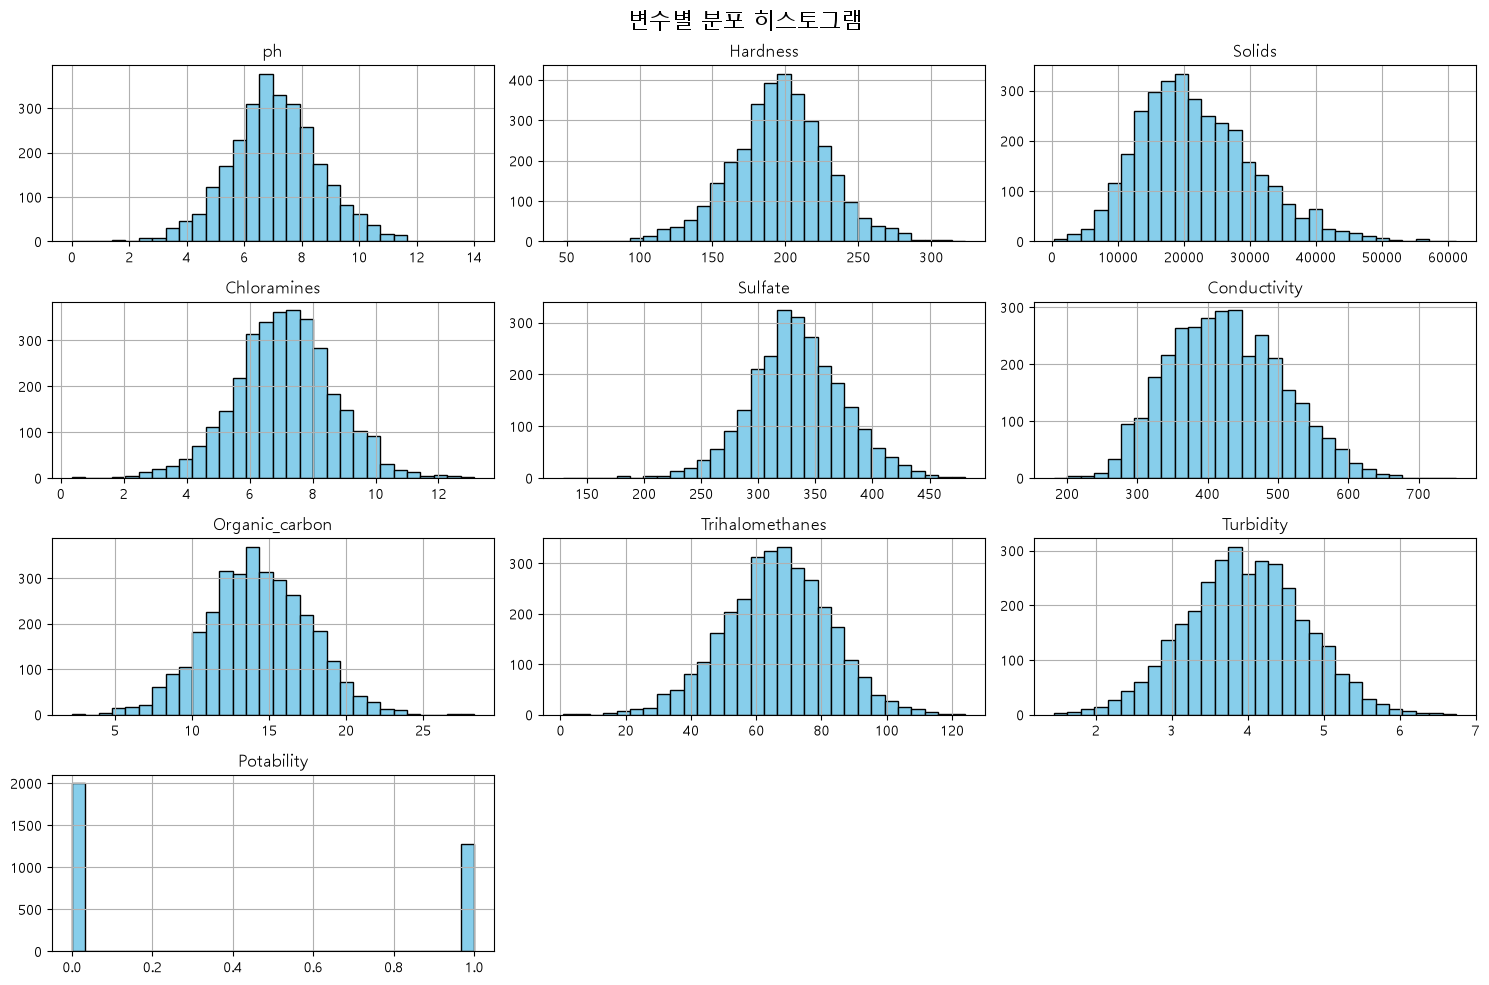

In [22]:
# 1. 전체 수치형 변수 분포 확인 (히스토그램)

water.hist(bins=30,            # 30개 구간으로 분리
           figsize=(15, 10),   # 그래프 크기
           color='skyblue',    # 그래프 색상
           edgecolor='black')  # 막대 테두리 색상
plt.suptitle('변수별 분포 히스토그램', fontsize=16)
plt.tight_layout()

'''
대부분의 변수가 대체로 정규분포에 가까운 종모양을 보이며,
ph, Sulfate, Trihalomethanes는 결측치로 인해 다른 변수보다 표본 수가 적을 수 있음
'''
plt.show()




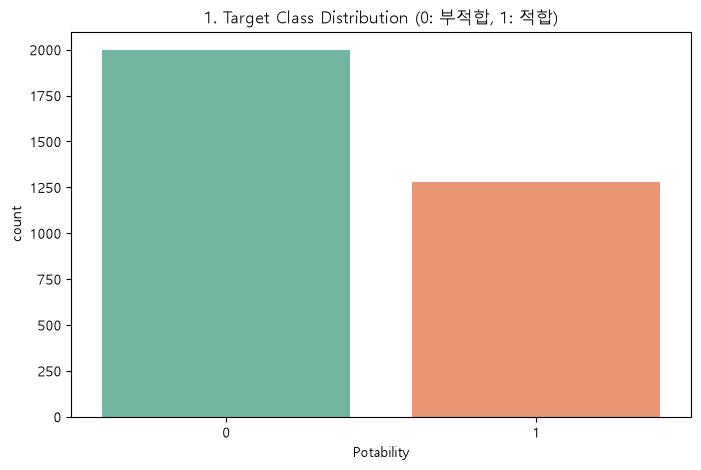

In [ ]:
# 2. 타겟 변수(Potability) 클래스 비율 확인

plt.figure(figsize=(8, 5))

# 데이터 개수 그래프
sns.countplot(x='Potability',   # x 값
              data=water,       # 데이터
              hue='Potability', # 그래프 색상 기준
              palette='Set2',   # 색상테마
              legend=False)     # 범례 미표시
plt.title('1. Target Class Distribution (0: 부적합, 1: 적합)')


'''
0(부적합) 데이터가 1(적합)보다 많음. 
타겟 데이터가 불균형(Imbalanced)하므로 
적합한 것을 찾는 것이 중요함

'''
plt.show()

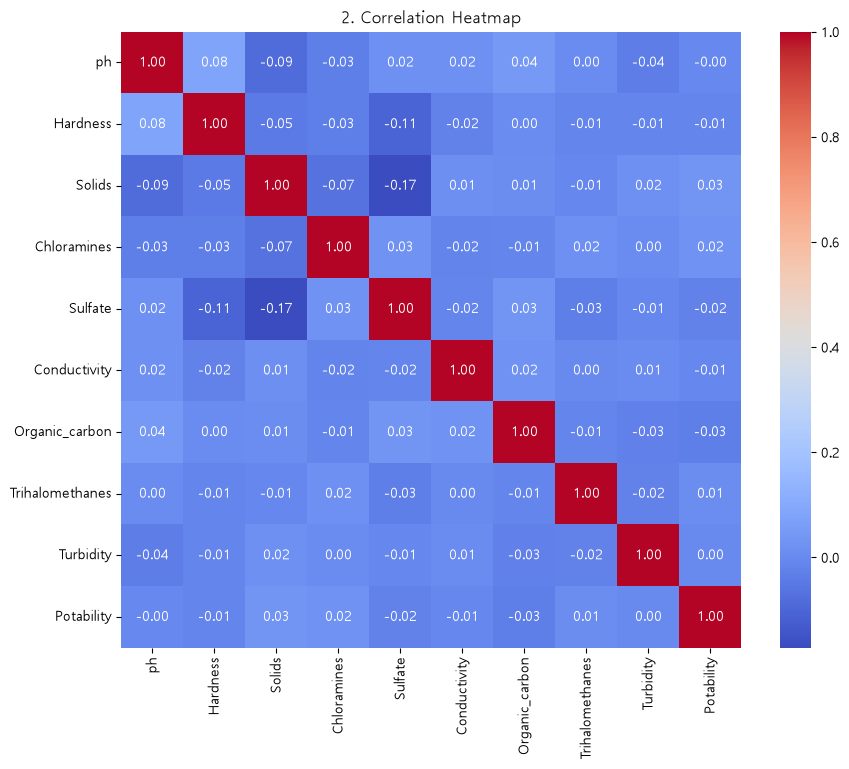

In [24]:
# 3. 특성 간 상관관계 히트맵

plt.figure(figsize=(10, 8))
sns.heatmap(water.corr(),    # 상관관계 계산
            annot=True,      # 수치 표시
            fmt=".2f",       # 소수점 둘째자리
            cmap='coolwarm') # 테마
plt.title('2. Correlation Heatmap')

'''
변수들 간의 상관계수가 대부분 0에 가깝습니다. 
서로 강한 선형 관계를 맺고 있는 변수가 없으므로, 
다중공선성(Multi-collinearity) 문제는 크게 걱정하지 않아도 됩니다.
(다중공선성 : 같은 정보가 중복되어 모델 학습에 방해가 되는 현상)
'''
plt.show()

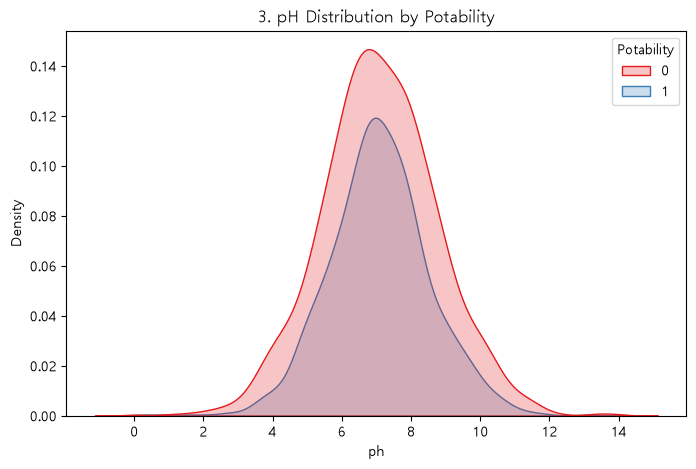

In [ ]:
# 4. Potability에 따른 pH 수치 분포 (KDE Plot)

plt.figure(figsize=(8, 5))

# 부드러운 곡선의 히스토그램이라고 생각하면 됨
sns.kdeplot(data=water, 
            x='ph', 
            hue='Potability', 
            fill=True, 
            palette='Set1')
plt.title('3. pH Distribution by Potability')

'''
적합(1)과 부적합(0)의 pH 분포가 거의 완벽하게 겹쳐 있는 종 모양(정규분포)을 보입니다. 
선형 모델보다는 패턴을 더 섬세하게 파악하는 앙상블 트리(Random Forest 등)나 비선형 모델이 적합해 보입니다.
KDE 플롯에서 두 그룹이 겹쳐 보인다는 것은, 
단 하나의 기준(단일 변수)으로는 정답을 맞힐 수 없다는 뜻. 

여러 변수를 조합하여 아주 복잡한 구조를 만들어야만 정답을 걸러낼 수 있는데, 
그 기법이 비선형 모델과 앙상블 모델

'''

plt.show()

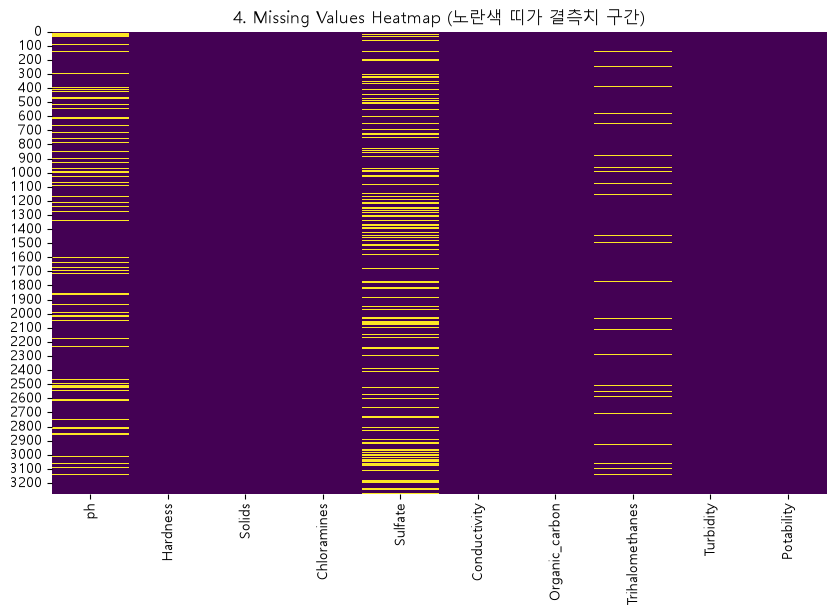

In [26]:
# 5. 결측치(Missing Value) 현황 시각화

plt.figure(figsize=(10, 6))
sns.heatmap(water.isnull(), cbar=False, cmap='viridis')
plt.title('4. Missing Values Heatmap (노란색 띠가 결측치 구간)')

'''
시각화 결과 ph, Sulfate, Trihalomethanes 3개의 컬럼에서 다수의 결측치가 관찰됩니다. 
빈 공간을 어떻게 메우느냐(평균값 대체 등)가 모델 성능에 영향을 미치게 됩니다.
'''

plt.show()



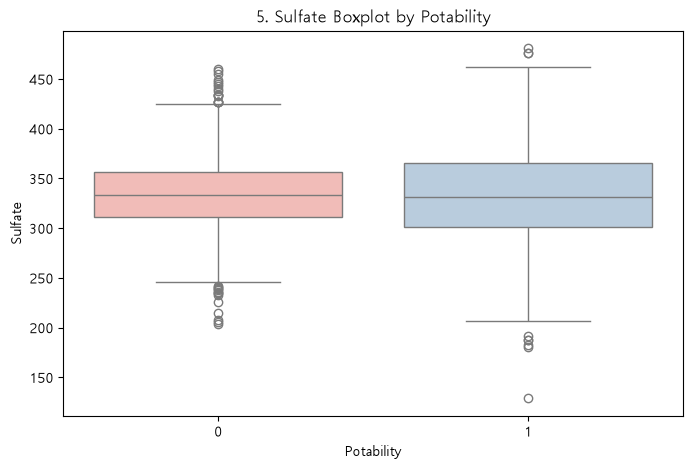

In [27]:
# 6. 주요 변수(Sulfate)의 Boxplot (이상치 확인)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Potability', y='Sulfate', data=water, hue='Potability', palette='Pastel1', legend=False)
plt.title('5. Sulfate Boxplot by Potability')

'''
수치들의 박스플롯을 보면, 위아래로 점(이상치, Outlier)들이 많이 찍혀있음. 
결측치를 평균으로 채울지 중앙값으로 채울지 고민할 때, 참고해야함
'''

plt.show()


## 3. missing value가 존재한다면 해당 컬럼의 평균값으로 대체

In [46]:
# 결측치(Missing Value) 처리 (평균값 대체)
print("\n[결측치 처리 전]")
print(water.isnull().sum()[water.isnull().sum() > 0])

# 숫자형 컬럼의 결측치를 각 컬럼의 평균값으로 채움
water.fillna(water.mean(), inplace=True)

print("\n[결측치 처리 후]")
print(water.isnull().sum()) # 모두 0이 나와야 정상


[결측치 처리 전]
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

[결측치 처리 후]
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


## 4. potability 를 예측 모델만들기

 - 머신러닝 알고리즘을 3개 이상 선택하고 
 - 각 알고리즘에 맞는 전처리와 하이퍼 파라미터를 찾고 
 - 최고 성능을 나타내는 모델과 모델 파라미터를 설명

In [47]:
# 4-1. 데이터 분할 및 스케일링(전처리)

x = water.drop('Potability', axis=1)
y = water['Potability']

# 훈련셋/테스트셋 분리 (계층적 분할 stratify=y 적용)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=260707, stratify=y)

In [ ]:
# # 1. 빈 파이프라인 껍데기 생성 (이름만 지정해 둡니다)
# pipe = Pipeline([
#     ('preprocess', StandardScaler()),
#     ('classifier', KNeighborsClassifier())
# ])

# # 2. 다중 모델 하이퍼파라미터 그리드 셋업
# param_grid = [

#     # 1. MLP Classifier 
#     {'preprocess': [StandardScaler()], 
#      'classifier': [MLPClassifier(random_state=260707)],
#      'classifier__hidden_layer_sizes': [(100,), (50, 50)], 
#      'classifier__activation': ['relu'],                  
#      'classifier__alpha': [0.0001, 0.01],                         
#      'classifier__max_iter': [3000]},

#     # 2. SVC (RBF 커널) 
#     {'preprocess': [StandardScaler()],
#      'classifier': [SVC(random_state=260707)],
#      'classifier__kernel': ['rbf'],
#      'classifier__gamma': ['scale', 'auto', 0.1], 
#      'classifier__C': [0.1, 1, 10]},

#     # 3. Random Forest 
#     {'preprocess': [None],
#      'classifier': [RandomForestClassifier(random_state=260707)],
#      'classifier__n_estimators': [100, 200],
#      'classifier__criterion': ['gini']},

#     # 4. Gradient Boosting Classifier
#     {'preprocess': [None], 
#      'classifier': [GradientBoostingClassifier(random_state=260707)],
#      'classifier__n_estimators': [100, 200],
#      'classifier__learning_rate': [0.05, 0.1], 
#      'classifier__max_depth': [3, 5]},          

#     # 5. KNeighborsClassifier 
#     {'preprocess': [StandardScaler()], 
#      'classifier': [KNeighborsClassifier()],
#      'classifier__n_neighbors': [5, 7, 9],
#      'classifier__weights': ['uniform', 'distance']}
# ]

# # 3. GridSearchCV 실행 세팅
# grid = GridSearchCV(pipe,
#                     param_grid,
#                     cv=5,
#                     return_train_score=True,
#                     verbose=3) 

# # 4. 학습 시작
# grid.fit(x_train, y_train)

# print("최고의 모델과 파라미터 조합:", grid.best_params_)
# print("최고 교차 검증 점수(Accuracy):", grid.best_score_)


Fitting 5 folds for each of 29 candidates, totalling 145 fits
[CV 1/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,), classifier__max_iter=3000, preprocess=StandardScaler();, score=(train=0.879, test=0.628) total time=  13.0s
[CV 2/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,), classifier__max_iter=3000, preprocess=StandardScaler();, score=(train=0.883, test=0.659) total time=  14.9s
[CV 3/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,), classifier__max_iter=3000, preprocess=StandardScaler();, score=(train=0.887, test=0.631) total time=  17.8s
[CV 4/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,)

최고의 모델과 파라미터 조합: {'classifier': SVC(random_state=260707), 'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'preprocess': StandardScaler()}

최고 교차 검증 점수(Accuracy): 0.6721374045801526

# 번외 : 결측치를 중앙값으로 대체한 경우


In [ ]:

water = pd.read_csv('water_potability.csv')
water.head()

# 결측치(Missing Value) 처리 (중앙값 대체)
print("\n[결측치 처리 전]")
print(water.isnull().sum()[water.isnull().sum() > 0])

# 숫자형 컬럼의 결측치를 각 컬럼의 중앙값으로 채움
water.fillna(water.fillna(water.median()), inplace=True)

print("\n[결측치 처리 후]")
print(water.isnull().sum()) # 모두 0이 나와야 정상


[결측치 처리 전]
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

[결측치 처리 후]
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [37]:
x = water.drop('Potability', axis=1)
y = water['Potability']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=260707, stratify=y)

In [ ]:
# pipe = Pipeline([
#     ('preprocess', StandardScaler()),
#     ('classifier', KNeighborsClassifier())
# ])

# param_grid = [

#     # 1. MLP Classifier 
#     {'preprocess': [StandardScaler()], 
#      'classifier': [MLPClassifier(random_state=260707)],
#      'classifier__hidden_layer_sizes': [(100,), (50, 50)], 
#      'classifier__activation': ['relu'],                  
#      'classifier__alpha': [0.0001, 0.01],                         
#      'classifier__max_iter': [3000]},                      # 수치 조정 

#     # 2. SVC (RBF 커널) 
#     {'preprocess': [StandardScaler()],
#      'classifier': [SVC(random_state=260707)],
#      'classifier__kernel': ['rbf'],
#      'classifier__gamma': ['scale', 'auto', 0.1], 
#      'classifier__C': [0.1, 1, 10]},

#     # 3. Random Forest 
#     {'preprocess': [None],
#      'classifier': [RandomForestClassifier(random_state=260707)],
#      'classifier__n_estimators': [100, 200],
#      'classifier__criterion': ['gini']},

#     # 4. Gradient Boosting Classifier
#     {'preprocess': [None], 
#      'classifier': [GradientBoostingClassifier(random_state=260707)],
#      'classifier__n_estimators': [100, 200],
#      'classifier__learning_rate': [0.05, 0.1], 
#      'classifier__max_depth': [3, 5]},          

#     # 5. KNeighborsClassifier 
#     {'preprocess': [StandardScaler()], 
#      'classifier': [KNeighborsClassifier()],
#      'classifier__n_neighbors': [5, 7, 9],
#      'classifier__weights': ['uniform', 'distance']}
# ]
# grid = GridSearchCV(pipe,
#                     param_grid,
#                     cv=5,
#                     return_train_score=True,
#                     verbose=3) 

# grid.fit(x_train, y_train)
# print("최고의 모델과 파라미터 조합:", grid.best_params_)
# print("최고 교차 검증 점수(Accuracy):", grid.best_score_)

Fitting 5 folds for each of 29 candidates, totalling 145 fits
[CV 1/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,), classifier__max_iter=3000, preprocess=StandardScaler();, score=(train=0.861, test=0.662) total time=  14.5s
[CV 2/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,), classifier__max_iter=3000, preprocess=StandardScaler();, score=(train=0.864, test=0.649) total time=  14.1s
[CV 3/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,), classifier__max_iter=3000, preprocess=StandardScaler();, score=(train=0.876, test=0.662) total time=  13.5s
[CV 4/5] END classifier=MLPClassifier(random_state=260707), classifier__activation=relu, classifier__alpha=0.0001, classifier__hidden_layer_sizes=(100,)

최고의 모델과 파라미터 조합: {'classifier': SVC(random_state=260707), 'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'preprocess': StandardScaler()}

최고 교차 검증 점수(Accuracy): 0.6729007633587786

# 수업 복습

## 복습 1 유클리드 거리 계산


In [ ]:
x_data = np.array([[1,1],[1,2],[5,4],[5,5]])
y_data = np.array([0,0,1,1])

my_data = [2,2]

# 가장 가까운(유클리드 거리 기반) x_data의 y값을 return 하는 함수를 작성하시오

def my_distance(x_data, y_data, my_data):
    ret = 0
    ####### Edit Here #######
    distances = np.sqrt(                 # 루트씌우기
        np.sum((x_data - my_data)**2,    # 유클리드 거리 계산
               axis=1))                  # axis=1 은 각 행마다 더하기.
    min_index = np.argmin(               # 가장 앞에 나오는 가장 작은 거리의 값 하나만 뽑고 인덱스로 기억
                          distances)     # 계산한 거리
    ret = y_data[min_index]              # 해당 인덱스 y_data 값 가져오기
    #########################
    return ret

print(my_distance(x_data, y_data, my_data)) 

1
